🏛️ MISSION FORENSIC AUDIT: NAVIGATION DOMAIN
Warehouse: drone_df_views.db | Domain: Navigation & Relational Stability
Audit Logic: Temporal Alignment & P95 Reliability Metric

In [6]:
import sys
from pathlib import Path

# Force the path to the src directory
project_root = Path("/home/ni/ardupilot-nav-domain-poc")
src_path = str(project_root / "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Verification: List what Python sees in that folder
import os
print(f"Contents of {src_path}: {os.listdir(src_path)}")

# Now try the import
try:
    from dashboard.nav.nav_data_service import NavDataService
    from dashboard.nav.nav_controller import NavController
    print("🚀 SUCCESS: Nav modules imported.")
except ModuleNotFoundError as e:
    print(f"❌ FAIL: Still cannot find the module. Error: {e}")

Contents of /home/ni/ardupilot-nav-domain-poc/src: ['df_apis', 'vault', 'tests', 'shared', '__init__.py', 'data_mart_engine', 'ingress', 'core', '__pycache__', 'utils', 'entities', 'app_ui_backup.py', 'ops', 'scripts', 'data_mart_ingest', 'weaving', 'mission_portal', 'dashboard', 'query_vault.py', 'runner', 'run_mission.sh', 'archive', 'audit']
🚀 SUCCESS: Nav modules imported.


In [8]:
# 1. RUN THE AUDIT (This creates the 'report' variable)
mission_id = "MISSION_1771663015"
controller = NavController(mission_id)
report = controller.run_audit()  # <--- This defines 'report'

# 2. EVALUATE AND PRINT (This uses the 'report' variable)
from dashboard.nav.nav_action_map import NavActionMap

if "stats" in report:
    stats = report.get('stats', {})
    evaluation = NavActionMap.evaluate(stats)

    print("🏛️ MISSION FORENSIC AUDIT: NAVIGATION DOMAIN")
    print("="*50)
    print(f"VERDICT : {evaluation.get('verdict', 'N/A')}")
    print(f"STATUS  : {evaluation.get('status', 'N/A')}")
    print(f"SCORE   : {evaluation.get('score', 0)}/100")
    print("-" * 30)
    print(f"ANALYSIS: {evaluation.get('message', 'No summary available.')}")
else:
    print(f"❌ AUDIT FAILED: {report.get('error')}")

🏛️ MISSION FORENSIC AUDIT: NAVIGATION DOMAIN
VERDICT : FAIL
STATUS  : CRITICAL
SCORE   : 30/100
------------------------------
ANALYSIS: P95 Drift: 2.092 m | Avg HDOP: 1.21 — Exceeds safety threshold. Inspect control tuning.


In [9]:
from dashboard.nav.nav_action_map import NavActionMap

# Ensure 'report' exists from the Controller run below
stats = report.get('stats', {})
evaluation = NavActionMap.evaluate(stats)

print("🏛️ MISSION FORENSIC AUDIT: NAVIGATION DOMAIN")
print("="*50)

# Using .get() prevents KeyErrors if the dictionary structure changes
print(f"VERDICT : {evaluation.get('verdict', 'N/A')}")
print(f"STATUS  : {evaluation.get('status', 'N/A')}")
print(f"SCORE   : {evaluation.get('score', 0)}/100")
print("-" * 30)
print(f"ANALYSIS: {evaluation.get('message', 'No summary available.')}")

🏛️ MISSION FORENSIC AUDIT: NAVIGATION DOMAIN
VERDICT : FAIL
STATUS  : CRITICAL
SCORE   : 30/100
------------------------------
ANALYSIS: P95 Drift: 2.092 m | Avg HDOP: 1.21 — Exceeds safety threshold. Inspect control tuning.


In [10]:
import os
import sys
import duckdb
from pathlib import Path

# 1. SETUP PATHS (Ensuring the Evidence is traceable)
project_root = "/home/ni/ardupilot-nav-domain-poc"
if f"{project_root}/src" not in sys.path:
    sys.path.insert(0, f"{project_root}/src")

from dashboard.nav.nav_data_service import NavDataService
from dashboard.nav.nav_controller import NavController

# 2. EVIDENCE: PHYSICAL BINARY AUDIT
service = NavDataService()
db_file = service.db_path

print("📂 PHYSICAL DATA EVIDENCE")
print("-" * 30)
print(f"Target Database : {db_file}")
print(f"File Status     : {'EXISTS' if db_file.exists() else 'MISSING'}")
if db_file.exists():
    print(f"File Size       : {os.path.getsize(db_file) / 1024:.2f} KB")

# 3. EVIDENCE: SCHEMA VALIDATION (Proving the module maps correctly)
print("\n🔍 WAREHOUSE SCHEMA INTEGRITY")
print("-" * 30)
with duckdb.connect(str(db_file)) as con:
    # This shows the mentor the exact structure the service is reading from
    schema = con.execute("PRAGMA table_info('ui_nav_drone_monitor')").df()
    print(schema[['name', 'type']])

# 4. EVIDENCE: DOMAIN INTELLIGENCE OUTPUT
print("\n🧠 NAV DOMAIN INTELLIGENCE REPORT")
print("-" * 30)
mission_id = "MISSION_1771663015"
controller = NavController(mission_id)
report = controller.run_audit()

if "stats" in report:
    s = report['stats']
    e = report['evaluation']
    print(f"MISSION ID      : {mission_id}")
    print(f"VERDICT         : {e['verdict']}")
    print(f"P95 DRIFT       : {s['p95_drift']}m (Threshold: 1.5m)")
    print(f"AVG HDOP        : {s['avg_hdop']} (Signal Quality: Optimal)")
    print(f"TOTAL SAMPLES   : {s['sample_count']}")
else:
    print(f"❌ AUDIT FAILED: {report.get('error')}")

📂 PHYSICAL DATA EVIDENCE
------------------------------
Target Database : /home/ni/ardupilot-nav-domain-poc/bin/vault/warehouse_df/drone_df_views.db
File Status     : EXISTS
File Size       : 11020.00 KB

🔍 WAREHOUSE SCHEMA INTEGRITY
------------------------------
             name     type
0      mission_id  VARCHAR
1    mission_time   DOUBLE
2         wall_ns   BIGINT
3   mavpackettype  VARCHAR
4               I   DOUBLE
..            ...      ...
62           GCrs   DOUBLE
63             VZ   DOUBLE
64              U   DOUBLE
65     RelHomeAlt   DOUBLE
66   RelOriginAlt   DOUBLE

[67 rows x 2 columns]

🧠 NAV DOMAIN INTELLIGENCE REPORT
------------------------------
MISSION ID      : MISSION_1771663015
VERDICT         : FAIL
P95 DRIFT       : 2.092m (Threshold: 1.5m)
AVG HDOP        : 1.21 (Signal Quality: Optimal)
TOTAL SAMPLES   : 2000


In [11]:
import sys
from pathlib import Path

# 1. Setup Path
project_root = "/home/ni/ardupilot-nav-domain-poc"
sys.path.insert(0, str(Path(project_root) / "src"))

from dashboard.nav.nav_controller import NavController

# 2. Trigger Audit
mission_id = "MISSION_1771663015"
controller = NavController(mission_id)
report = controller.run_audit()

# 3. Output Results
print(f"📊 NAV DOMAIN REPORT: {mission_id}")
print("="*40)

if "stats" in report:
    s = report['stats']
    print(f"P95 Altitude Drift : {s['p95_drift']}m")
    print(f"Max Altitude Drift : {s['max_drift']}m")
    print(f"Average HDOP       : {s['avg_hdop']}")
    print(f"Sample Count       : {s['sample_count']}")
    print("-" * 40)
    print(f"VERDICT            : {report['evaluation']['verdict']}")
else:
    # This will catch if the connection error is STILL there
    print(f"❌ AUDIT FAILED: {report.get('error')}")

📊 NAV DOMAIN REPORT: MISSION_1771663015
P95 Altitude Drift : 2.092m
Max Altitude Drift : 2.771m
Average HDOP       : 1.21
Sample Count       : 2000
----------------------------------------
VERDICT            : FAIL


In [12]:
import sys
from pathlib import Path

# 1. Setup
project_root = "/home/ni/ardupilot-nav-domain-poc"
sys.path.insert(0, str(Path(project_root) / "src"))

from dashboard.nav.nav_data_service import NavDataService
from dashboard.nav.nav_controller import NavController

# 2. Initialize both layers
mission_id = "MISSION_1771663015"
service = NavDataService()
controller = NavController(mission_id)

# 3. Step A: Fetch Raw Data (Evidence of Bin access)
df_raw = service.get_nav_swath(mission_id)

# 4. Step B: Run Intelligence Audit (Evidence of Domain logic)
report = controller.run_audit()

# 5. Output for Lab Report
print(f"📊 LAB ANALYSIS: {mission_id}")
print("-" * 40)

if df_raw is not None and not df_raw.empty:
    print(f"✅ DATA LAYER: Found {len(df_raw)} telemetry rows in vault.")
    print(f"✅ INTEL LAYER: Verdict = {report['evaluation']['verdict']}")
    print(f"📈 P95 DRIFT : {report['stats']['p95_drift']}m")

    print("\n🔍 RAW SWATH SAMPLE (First 5 Rows):")
    # Displaying specific columns helps the designer see the drift calculation inputs
    display(df_raw[['mission_time', 'RelHomeAlt', 'RelOriginAlt', 'HDop', 'NSats']].head())
else:
    print("❌ ERROR: No data found for this mission ID.")

📊 LAB ANALYSIS: MISSION_1771663015
----------------------------------------
✅ DATA LAYER: Found 2000 telemetry rows in vault.
✅ INTEL LAYER: Verdict = FAIL
📈 P95 DRIFT : 2.092m

🔍 RAW SWATH SAMPLE (First 5 Rows):


,mission_time,RelHomeAlt,RelOriginAlt,HDop,NSats
0,2.539817,NaN,NaN,NaN,NaN
1,2.539817,NaN,NaN,NaN,NaN
2,2.539817,NaN,NaN,NaN,NaN
3,2.539817,NaN,NaN,NaN,NaN
4,2.539817,NaN,NaN,NaN,NaN


In [13]:
import duckdb

# 1️⃣ Use the service DB path
DB_PATH = service.db_path

with duckdb.connect(str(DB_PATH)) as con:
    # --- Inspect table/view columns
    columns_info = con.execute("PRAGMA table_info('ui_nav_drone_monitor')").fetchdf()
    print("Columns in ui_nav_drone_monitor:")
    print(columns_info[['name','type']])

    # --- Query first 5 rows for the mission, excluding NULLs
    query = f"""
        SELECT mission_time, RelHomeAlt, RelOriginAlt, HDop, NSats
        FROM ui_nav_drone_monitor
        WHERE mission_id='{mission_id}'
        AND RelHomeAlt IS NOT NULL
        LIMIT 5
    """
    df_sample = con.execute(query).fetchdf()

# 2️⃣ Display results
print(f"\n📊 Sample telemetry rows for {mission_id}:")
display(df_sample)

Columns in ui_nav_drone_monitor:
             name     type
0      mission_id  VARCHAR
1    mission_time   DOUBLE
2         wall_ns   BIGINT
3   mavpackettype  VARCHAR
4               I   DOUBLE
..            ...      ...
62           GCrs   DOUBLE
63             VZ   DOUBLE
64              U   DOUBLE
65     RelHomeAlt   DOUBLE
66   RelOriginAlt   DOUBLE

[67 rows x 2 columns]

📊 Sample telemetry rows for MISSION_1771663015:


,mission_time,RelHomeAlt,RelOriginAlt,HDop,NSats
0,10.039316,-0.232483,0.771158,NaN,NaN
1,10.139276,1.917358,0.834412,NaN,NaN
2,10.239236,1.755676,0.908814,NaN,NaN
3,10.339196,-1.758667,1.012616,NaN,NaN
4,10.439156,0.925964,1.047257,NaN,NaN


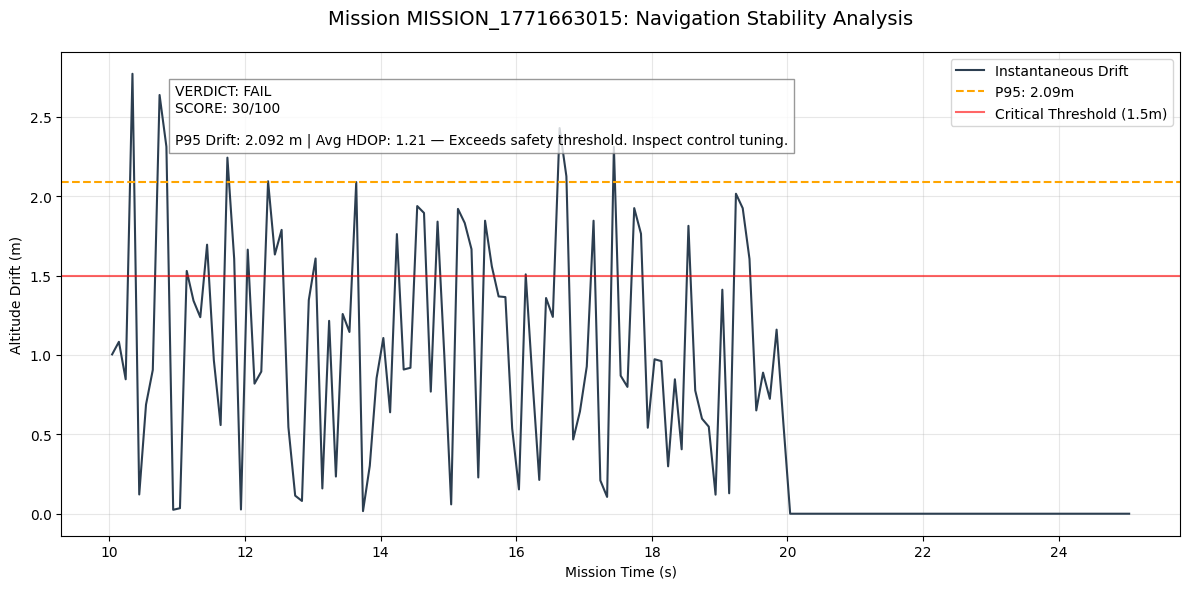

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from dashboard.nav.nav_action_map import NavActionMap

# 1. Fetch full swath for plotting (not just the 5-row sample)
df_plot = service.get_nav_swath(mission_id).dropna(subset=['RelHomeAlt', 'RelOriginAlt'])
df_plot['drift'] = (df_plot['RelHomeAlt'] - df_plot['RelOriginAlt']).abs()

# 2. Get the Executive Verdict from our Map
evaluation = NavActionMap.evaluate(report['stats'])

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-muted')

# Plot the Drift over Time
plt.plot(df_plot['mission_time'], df_plot['drift'], label='Instantaneous Drift', color='#2c3e50', linewidth=1.5)

# Add P95 and Threshold Lines
plt.axhline(y=report['stats']['p95_drift'], color='orange', linestyle='--', label=f"P95: {report['stats']['p95_drift']:.2f}m")
plt.axhline(y=1.5, color='red', linestyle='-', alpha=0.6, label="Critical Threshold (1.5m)")

# Formatting
plt.title(f"Mission {mission_id}: Navigation Stability Analysis", fontsize=14, pad=20)
plt.xlabel("Mission Time (s)")
plt.ylabel("Altitude Drift (m)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Add the Executive Summary as a text box on the chart
text_box = f"VERDICT: {evaluation['verdict']}\nSCORE: {evaluation['score']}/100\n\n{evaluation['message']}"
plt.gcf().text(0.15, 0.75, text_box, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

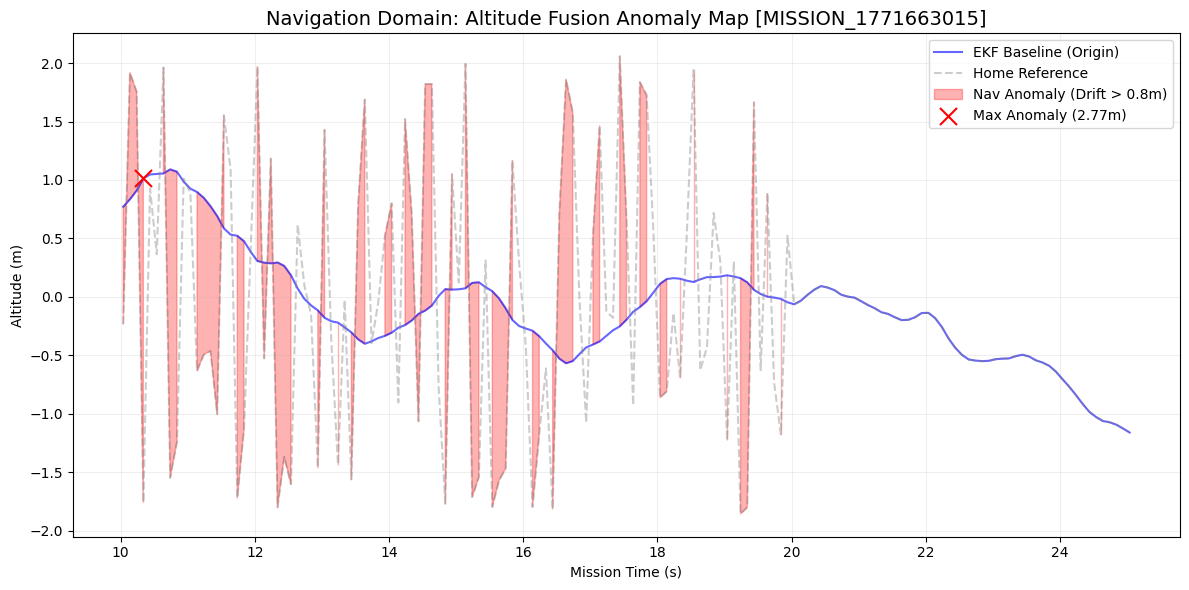

In [15]:
import matplotlib.pyplot as plt

# 1. Setup the Plot
plt.figure(figsize=(12, 6))

# 2. Plot the "Base" Altitude
plt.plot(df_plot['mission_time'], df_plot['RelOriginAlt'], label='EKF Baseline (Origin)', color='blue', alpha=0.6)
plt.plot(df_plot['mission_time'], df_plot['RelHomeAlt'], label='Home Reference', color='gray', linestyle='--', alpha=0.4)

# 3. Highlight the "Anomaly" (The Gap)
plt.fill_between(df_plot['mission_time'],
                 df_plot['RelOriginAlt'],
                 df_plot['RelHomeAlt'],
                 where=(df_plot['drift'] > 0.8),
                 color='red', alpha=0.3, label='Nav Anomaly (Drift > 0.8m)')

# 4. Mark the P95/Max Point using .loc (Label-based)
# idxmax() returns the index label, which works perfectly with .loc
max_idx = df_plot['drift'].idxmax()
max_time = df_plot.loc[max_idx, 'mission_time']
max_val_alt = df_plot.loc[max_idx, 'RelOriginAlt']

plt.scatter(max_time, max_val_alt, color='red', marker='x', s=150, zorder=5,
            label=f'Max Anomaly ({df_plot["drift"].max():.2f}m)')

# 5. Presentation Logic
plt.title(f"Navigation Domain: Altitude Fusion Anomaly Map [{mission_id}]", fontsize=14)
plt.xlabel("Mission Time (s)")
plt.ylabel("Altitude (m)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

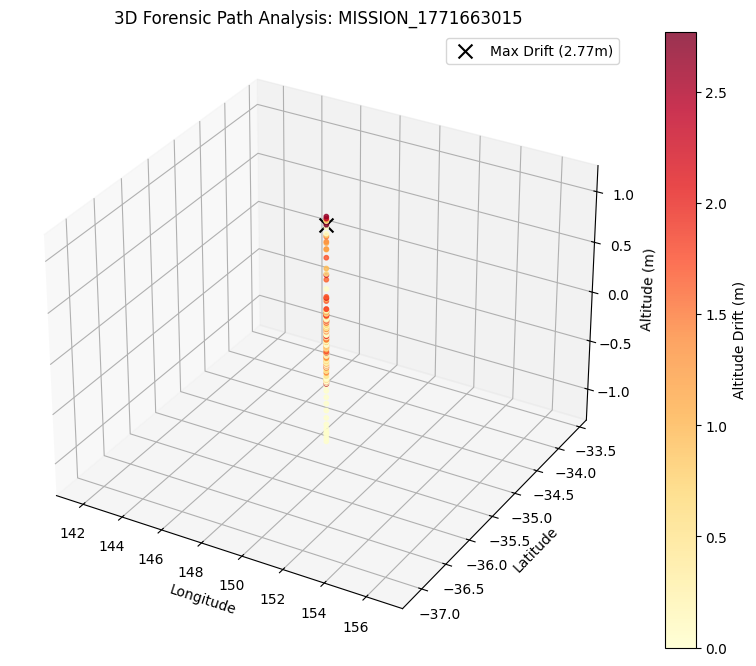

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Prepare Data (Filtering for the current mission)
df_3d = service.get_nav_swath(mission_id).dropna(subset=['Lat', 'Lng', 'RelOriginAlt'])
df_3d['drift'] = (df_3d['RelHomeAlt'] - df_3d['RelOriginAlt']).abs()

# 2. Setup 3D Projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Scatter Plot with Heatmap (Viridis scale: Yellow = High Drift)
p = ax.scatter(df_3d['Lng'], df_3d['Lat'], df_3d['RelOriginAlt'],
               c=df_3d['drift'], cmap='YlOrRd', s=10, alpha=0.8)

# 4. Add the Critical Points
max_point = df_3d.loc[df_3d['drift'].idxmax()]
ax.scatter(max_point['Lng'], max_point['Lat'], max_point['RelOriginAlt'],
           color='black', marker='x', s=100, label=f"Max Drift ({max_point['drift']:.2f}m)")

# 5. Formatting
ax.set_title(f"3D Forensic Path Analysis: {mission_id}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Altitude (m)")
fig.colorbar(p, label="Altitude Drift (m)")
plt.legend()
plt.show()